<a href="https://colab.research.google.com/github/PrarthanaShende/AI-Projects-/blob/main/power_energy_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Build an ANN model that predicts the power energy generated by the powerplant by taking various sensor readings into consideration.

### Data Gathering

In [1]:

import pandas as pd
path= r'https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/PowerPlant.csv'
df=pd.read_csv(path)
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


## Perform basic data quality checks

In [2]:

df.shape

(9568, 5)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [4]:
df.duplicated().sum()  # Check for the duplicated rows

np.int64(41)

In [5]:
df=df.drop_duplicates()  # drop the duplicates

In [6]:
# Check for Missing values
df.isna().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


## Separate X and Y features

In [7]:
df.columns

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')

In [8]:
X=df.drop(columns='PE')
Y=df[['PE']]

In [9]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [10]:
Y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


## Feature Engg : Data Preprocessing - Data Cleaning and Data Scaling

In [11]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

pre = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
).set_output(transform='pandas')

In [12]:

X_pre =pre.fit_transform(X)
X_pre.head()

,AT,V,AP,RH
0,-1.520448,-1.066041,-0.403535,1.141599
1,0.534897,0.330813,-0.309262,0.059223
2,1.354348,0.205475,-1.024725,-2.151400
3,-0.079020,-0.362884,-1.012941,0.236538
4,-1.055645,-1.074713,0.655349,1.633837


## Split the data into training and testing

In [13]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest =train_test_split(X_pre,Y,train_size=0.75,random_state=42)

In [14]:
Y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


## Model Building

In [15]:
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.callbacks import EarlyStopping

In [16]:
# Intialize the model
model= Sequential()

# Add the Input layer
model.add(Input(shape=(xtrain.shape[1],)))

# Add the Hidden layer 1
model.add(Dense(units=32,activation='relu'))

# Add the Output layer
model.add(Dense(units=1,activation='linear'))

In [17]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

In [18]:
nn=model.fit(xtrain,ytrain,validation_split=0.2,epochs=80)

Epoch 1/80
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 204715.0781 - mean_absolute_error: 452.1103 - val_loss: 201833.2031 - val_mean_absolute_error: 448.8838
Epoch 2/80
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 198988.7188 - mean_absolute_error: 445.6865 - val_loss: 193464.1562 - val_mean_absolute_error: 439.3975
Epoch 3/80
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 188178.2500 - mean_absolute_error: 433.2819 - val_loss: 179713.1562 - val_mean_absolute_error: 423.3065
Epoch 4/80
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 172550.2656 - mean_absolute_error: 414.6113 - val_loss: 161791.0938 - val_mean_absolute_error: 401.2083
Epoch 5/80
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 153582.5625 - mean_absolute_error: 390.5523 - val_loss: 141321.6562 - val_mean_absolute_error: 374.0678
Epoch 6/80
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 132746.1719 - mean_absolute_error: 361.9306 - val_loss: 119625.4609 - val_mean_absolute_error: 342.4561
Epoch 7/80
179/1

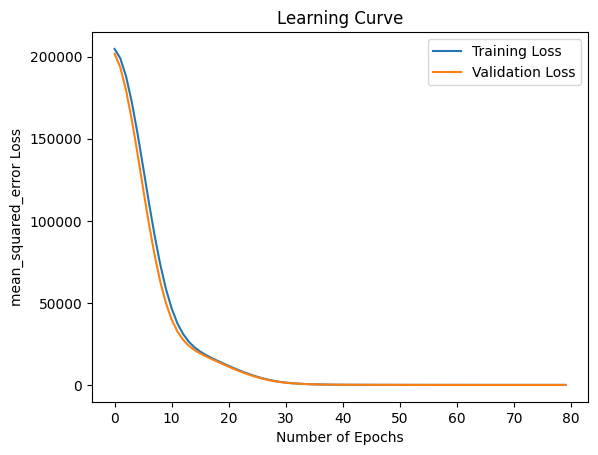

In [24]:
import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label='Training Loss')
plt.plot(nn.history['val_loss'],label='Validation Loss')
plt.xlabel("Number of Epochs")
plt.ylabel("mean_squared_error Loss")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [20]:
model.evaluate(xtrain,ytrain)

224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.6528 - mean_absolute_error: 3.4872


[19.652841567993164, 3.4872000217437744]

In [21]:
model.evaluate(xtest,ytest)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.3723 - mean_absolute_error: 3.4637


[19.372268676757812, 3.463731050491333]

In [22]:
# Predictions
y_pred = model.predict(xtest)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [23]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

mse_te = mean_squared_error(ytest,y_pred)
mae_te = mean_absolute_error(ytest,y_pred)
rmse_te = mse_te**(1/2)
r2_te = r2_score(ytest,y_pred)

print("==========================")
print("Testing Scores")
print(f"MSE:{mse_te}")
print(f"RMSE:{rmse_te}")
print(f"MAE:{mae_te}")
print(f"R2:{r2_te}")

Testing Scores
MSE:19.372264862060547
RMSE:4.401393513656845
MAE:3.463731050491333
R2:0.9350504279136658
